<a href="https://colab.research.google.com/github/Joel-Alejandro-DM/DrivenPath/blob/main/L05_Red_Neuronal_Densa_TF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Red Neuronal Densa en TensorFlow
## Dr. Carlos Villaseñor

Paso 1. Correr paqueterias

In [1]:
# Paquetería básica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos Tensorflow y Keras
import tensorflow as tf
from tensorflow import keras

# Usamos funcionalidades básicas de Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Paso 2. Carga el archivo 'auto-mpg.csv' y haz la lectura con pandas

In [24]:
!wget 'https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/auto-mpg.csv'

--2025-10-01 03:00:53--  https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/auto-mpg.csv
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/auto-mpg.csv [following]
--2025-10-01 03:00:53--  https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/auto-mpg.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18131 (18K) [text/plain]
Saving to: ‘auto-mpg.csv.3’

auto-mpg.csv.3      100%[===================>]  17.71K  --.-KB/s    in 0.001s  

2025-10-01 03:00:53 (15.4 M

In [66]:
dataset = pd.read_csv('auto-mpg.csv')
dataset.head

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


Paso 3. Limpieza de los datos

In [78]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    object 
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   car name      392 non-null    object 
 8   USA           392 non-null    float64
 9   Europe        392 non-null    float64
 10  Japan         392 non-null    float64
dtypes: float64(6), int64(3), object(2)
memory usage: 36.8+ KB


In [67]:
np.array(dataset.horsepower)

array(['130', '165', '150', '150', '140', '198', '220', '215', '225',
       '190', '170', '160', '150', '225', '95', '95', '97', '85', '88',
       '46', '87', '90', '95', '113', '90', '215', '200', '210', '193',
       '88', '90', '95', '?', '100', '105', '100', '88', '100', '165',
       '175', '153', '150', '180', '170', '175', '110', '72', '100', '88',
       '86', '90', '70', '76', '65', '69', '60', '70', '95', '80', '54',
       '90', '86', '165', '175', '150', '153', '150', '208', '155', '160',
       '190', '97', '150', '130', '140', '150', '112', '76', '87', '69',
       '86', '92', '97', '80', '88', '175', '150', '145', '137', '150',
       '198', '150', '158', '150', '215', '225', '175', '105', '100',
       '100', '88', '95', '46', '150', '167', '170', '180', '100', '88',
       '72', '94', '90', '85', '107', '90', '145', '230', '49', '75',
       '91', '112', '150', '110', '122', '180', '95', '?', '100', '100',
       '67', '80', '65', '75', '100', '110', '105', '140', '1

In [68]:
dataset['horsepower'].replace('?', np.nan, inplace=True)
np.array(dataset.horsepower)

/tmp/ipython-input-1018419082.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['horsepower'].replace('?', np.nan, inplace=True)


array(['130', '165', '150', '150', '140', '198', '220', '215', '225',
       '190', '170', '160', '150', '225', '95', '95', '97', '85', '88',
       '46', '87', '90', '95', '113', '90', '215', '200', '210', '193',
       '88', '90', '95', nan, '100', '105', '100', '88', '100', '165',
       '175', '153', '150', '180', '170', '175', '110', '72', '100', '88',
       '86', '90', '70', '76', '65', '69', '60', '70', '95', '80', '54',
       '90', '86', '165', '175', '150', '153', '150', '208', '155', '160',
       '190', '97', '150', '130', '140', '150', '112', '76', '87', '69',
       '86', '92', '97', '80', '88', '175', '150', '145', '137', '150',
       '198', '150', '158', '150', '215', '225', '175', '105', '100',
       '100', '88', '95', '46', '150', '167', '170', '180', '100', '88',
       '72', '94', '90', '85', '107', '90', '145', '230', '49', '75',
       '91', '112', '150', '110', '122', '180', '95', nan, '100', '100',
       '67', '80', '65', '75', '100', '110', '105', '140', '1

In [69]:
dataset = dataset.dropna()

Paso 3. Revisar datos faltantes

In [70]:
dataset.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


Paso 6. Condificación one-hot a columnas del país

In [76]:
origin = dataset.pop('origin')
dataset['USA'] = (origin == 1)*1.0
dataset['Europe'] = (origin == 2)*1.0
dataset['Japan'] = (origin == 3)*1.0
dataset.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name,USA,Europe,Japan
393,27.0,4,140.0,86,2790,15.6,82,ford mustang gl,1.0,0.0,0.0
394,44.0,4,97.0,52,2130,24.6,82,vw pickup,0.0,1.0,0.0
395,32.0,4,135.0,84,2295,11.6,82,dodge rampage,1.0,0.0,0.0
396,28.0,4,120.0,79,2625,18.6,82,ford ranger,1.0,0.0,0.0
397,31.0,4,119.0,82,2720,19.4,82,chevy s-10,1.0,0.0,0.0


Paso 7. Elige las variables de entrada y salida

In [109]:
x = np.asanyarray(dataset.drop(columns=['mpg', 'car name']))
# print(x)
# print(x[0])
y = np.asanyarray(dataset[['mpg']])
x = StandardScaler().fit_transform(x)
print(x.shape)
print(y.shape)


# data2 = dataset.copy()

# data2['mpg'] = y
# # data2['cylinders'], data2['displacement'], data2['horsepower'], data2['weight'], data2['model year'], data2['USA'], data2['Europe'], data2['Japan'] = x[0]
# data2.head()


(392, 9)
(392, 1)


Paso 8. Particiona el dataset

In [110]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2)

Paso 9. Crea una red neuronal para aprender los datos. En este caso creamos la metrica de regresión R2,

In [142]:
from tensorflow.keras import backend as K

def r2score(y_true, y_pred):
    SS_res = K.sum(K.square(y_true - y_pred))
    SS_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - SS_res / (SS_tot + K.epsilon())

In [131]:
def build_model():

  model = keras.Sequential()
  model.add(keras.layers.Dense(128, activation='relu', input_shape=[x.shape[1]]))
  model.add(keras.layers.Dropout(0.2))
  model.add(keras.layers.Dense(32, activation='tanh'))
  model.add(keras.layers.Dense(1, activation='linear'))

  model.compile(loss='mean_squared_error',
                optimizer=keras.optimizers.Adam(),
                metrics=[keras.metrics.MAE, r2score])
  return  model

In [143]:
model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

Paso 10. Entrena la red neuronal

In [144]:
history = model.fit(xtrain, ytrain,
                    batch_size=150, epochs=3000,
                    validation_data=(xtest, ytest), verbose=1)

Se han truncado las últimas 5000 líneas del flujo de salida.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 11.4369 - mean_absolute_error: 2.2799 - r2score: 0.8031 - val_loss: 17.6248 - val_mean_absolute_error: 2.6759 - val_r2score: 0.7083
Epoch 502/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 11.5776 - mean_absolute_error: 2.2844 - r2score: 0.8179 - val_loss: 17.5701 - val_mean_absolute_error: 2.6688 - val_r2score: 0.7092
Epoch 503/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 11.7980 - mean_absolute_error: 2.2738 - r2score: 0.8182 - val_loss: 17.4956 - val_mean_absolute_error: 2.6665 - val_r2score: 0.7104
Epoch 504/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 11.4949 - mean_absolute_error: 2.2975 - r2score: 0.8015 - val_loss: 17.4276 - val_mean_absolute_error: 2.6726 - val_r2score: 0.7116
Epoch 505/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 11.8620 - mean_absolute_error: 2.3460 - r2score: 0.7851 - val_loss: 17.3384 - val_mean_absolute_error: 2.6692 - val_r2sco

Paso 11. Dibuja las curvas de aprendizaje para un mejor diagnóstico del aprendizaje

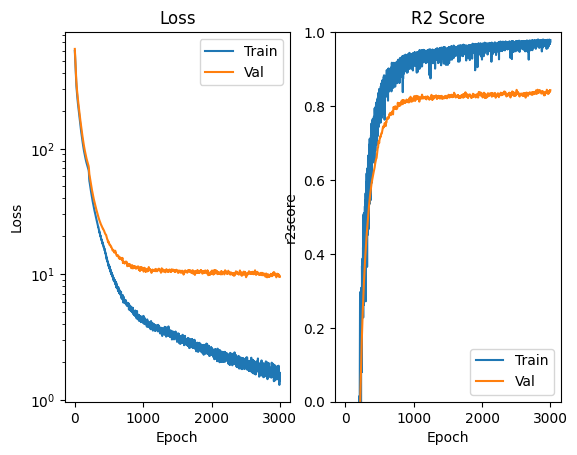

In [145]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure()
  plt.subplot(121)
  plt.title('Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_loss'],
           label = 'Val')
  plt.yscale('log')
  plt.legend()

  plt.subplot(122)
  plt.title('R2 Score')
  plt.xlabel('Epoch')
  plt.ylabel('r2score')
  plt.plot(hist['epoch'], hist['r2score'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_r2score'],
           label = 'Val')
  plt.ylim([0,1])
  plt.legend()

plot_history(history)

Paso 12. Implementación de Eary Stopping como regulador

Epoch 1/3000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - loss: 594.4023 - mean_absolute_error: 23.1607 - r2score: -9.5234 - val_loss: 608.7770 - val_mean_absolute_error: 23.4824 - val_r2score: -9.0759
Epoch 2/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 572.5911 - mean_absolute_error: 22.7463 - r2score: -8.4673 - val_loss: 587.1103 - val_mean_absolute_error: 23.0412 - val_r2score: -8.7173
Epoch 3/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 551.7271 - mean_absolute_error: 22.2607 - r2score: -8.3031 - val_loss: 566.1360 - val_mean_absolute_error: 22.6017 - val_r2score: -8.3701
Epoch 4/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 529.0918 - mean_absolute_error: 21.8041 - r2score: -8.0621 - val_loss: 545.6375 - val_mean_absolute_error: 22.1619 - val_r2score: -8.0309
Epoch 5/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 513.2238 - mean_absolute_error: 21.4004 - r2score: -7.5566 - val_loss: 525.3994 - val_mean_absolute_error: 21.7190 - val_r2score: -7.6959
Epoch 6/3000
3/3 ━━━━━━━━━━

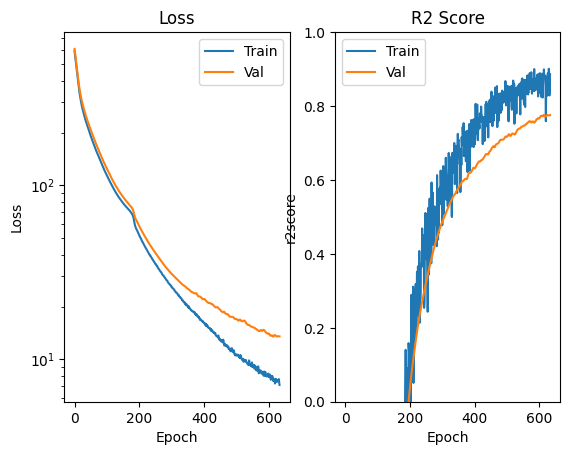

In [146]:
es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=20)
model = build_model()
history = model.fit(xtrain, ytrain,
                    batch_size=150, epochs=3000,
                    validation_data=(xtest, ytest),
                    verbose=1, callbacks=[es])
plot_history(history)